# Spotify Lab: Vectors, Inner Products, and Similar Songs

**Name(s):** Austin Alvarado

You are a new data engineer at Spotify.

When a listener asks for songs with similar content, we want to query the library of music and select appropriate recommendations. 

Every song is represented as a vector, and we are using a **vector database**: Each song is encoded as a vector of word counts. So if "love" appears 12 times in the song, the "love" coordinate is $x_{\text{love}}=12$. If Metallica writes songs about topics that are more similar to Black Sabbath than to Josh Groban, then the vector representations of their songs will have more similar profiles, and we should suggest Black Sabbath over Josh Groban. This approach is fundamental to technologies like LLMs or facial recognition, which store documents and faces as vectors and conducts fast look-ups using the kinds of math we'll look at in this lab.

The main data, `song_vectors.csv.gz`, include:

- `track_id`, `song_id`, `artist_id`: Internal unique track identifiers
- `artist_name`, `song_title`, `release`: Artist, song, album
- `release_year`, `duration`: `
- `artist_familiarity`, `artist_hotttnesss`: Measures of ubiquity, popularity
- `genre`, `top_tags`: Information about the song type
- `n_words`, `nnz_words`, `l2_norm`: Number of total words in the song, number of non-zero word coordinates (i.e. number of unique words), and the word counts squared/summed/square-rooted.
- `is_test`: Train-test split identification
- 800 columns of word counts

The `top_40_songs_by_genre.csv` file contains the top 40 songs by genre -- rock, metal, pop, punk, country, r&b/soul, folk, hip hop, electronic, blues, jazz, reggae, latin, classical -- by "hotttness". We'll use these songs to benchmark.

The `vocabulary.csv` file includes the 800 words that form the vector space in which the songs are modeled.

Each song becomes a vector of lyric-word counts, and then we use vector operations to quantify "similarity".

The big goal of this lab is simple:

**Vectors and inner products and vector length are the core tools of modern retrieval systems.**

## Lab Overview and Submission

**Add your name to the top of this notebook and name anyone you worked closely with.** Add this notebook to a personal GitHub repository and submit the repository link in Canvas. Every group member should be able to explain the code and conclusions in the submitted work.

The goal of this lab is to use vectors and inner products to build, inspect, and critique a small song-recommendation system. You will represent songs using lyric word counts, compare several measures of similarity, and decide which measure produces the most useful recommendations.

### Part 1: Basic Similarity Measures

Complete the steps in this notebook. For each method, run the code, inspect the rankings and plots, and respond to the yellow prompts in your own words. Explain what the score measures, how the top matches change, and whether the method is rewarding genuine lyric similarity, song length, or some other pattern.

### Part 2: Recommendation Logic

Use cosine similarity to build the final 10-song recommendation list after excluding the query song itself. Evaluate that choice against the dot-product ranking. Identify at least two specific songs that illustrate an important difference between the rankings, and explain what that difference reveals about the two scoring rules.

### Short Written Explanation

At the end of this notebook, write a 2-4 paragraph response. State which similarity measure you would recommend Spotify use for this lyric-only prototype, justify your choice with results from your analysis, and discuss at least two concrete examples from the rankings. Briefly note one important limitation of lyric word counts alone and name information that could make a real recommendation system better.

Your completed submission should include this notebook with all code executed, outputs visible, and written responses included.

## Setup

We will use:

- `./data/song_vectors.csv.gz`: one row per song
- `./data/vocabulary.csv`: the word columns used in the song vectors

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


songs = pd.read_csv( "./data/song_vectors.csv.gz" )
vocab = pd.read_csv( "./data/vocabulary.csv" )
top_40 = pd.read_csv("./data/top_40_songs_by_genre.csv")

word_cols = vocab["word"].tolist() # Song count matrix
meta_cols = songs.columns.drop(word_cols).tolist() # Information about tracks

print('Number of songs, number of words:', songs.shape)
print( 'Song metadata fields:', meta_cols[:8])

Number of songs, number of words: (8000, 816)
Song metadata fields: ['track_id', 'song_id', 'artist_id', 'artist_name', 'song_title', 'release', 'release_year', 'duration']


In [2]:
songs[meta_cols].head()

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0
1,TRAAWOR128F92DF3C8,SOBJYXZ12A8AE45FF1,ARY80281187FB3E380,Sandi Thom,Wounded Hearts,The Pink & The Lily,2008,205.21751,0.655359,0.405031,blues,blues,287,103,39.698866,0
2,TRABNZS128F932C6E8,SOCOZZE12A813568F7,AROWOZ41187FB5B535,G. Love & Special Sauce,Willow Tree,Yeah_ It's That Easy,1997,206.57587,0.717235,0.548694,blues,blues; chill; alternative; rock; jazz,211,64,33.090784,0
3,TRABOIH128F9300B06,SOHYOTB12AF72AA1D7,AR94ZOI1187FB46BDA,Willie Dixon,That's My Baby,Very Best Of The Blues,1989,208.90077,0.579533,0.429834,blues,delta blues; BLUEZZZ; blues; freedom; Willie D...,164,76,27.477263,0
4,TRABYAR128F931B1A4,SOVKUOE12A58A8066E,AR7BMMV1187FB5B2D7,Robben Ford,Something For The Pain,Blue Moon,2002,298.37016,0.604820,0.383877,blues,blues; Robben Ford; vinnie colaiuta; jimmy earl,187,75,27.604347,0


## Part 1: Similarity Measures for Song Vectors

The word-count columns are coordinates. That means each song is a vector in a high-dimensional space.

We will work with the song-by-word matrix $X$, where each row is one song vector.

In [3]:
X = songs[word_cols].to_numpy(dtype=float)

query_idx = 0 # Let's query the first song
query = X[query_idx]

print( 'Track metadata: \n')
print(songs.loc[query_idx, meta_cols])

print( 'Track word counts: \n')
print( query )

Track metadata: 

track_id                                            TRAAPIV128F1493132
song_id                                             SOJHKYL12A6D4FA0AC
artist_id                                           AR56P361187B9AC4DB
artist_name                                                 Gary Moore
song_title                                        What Are We Here For
release                                          Dark Days In Paradise
release_year                                                      1997
duration                                                     345.93914
artist_familiarity                                            0.761362
artist_hotttnesss                                             0.467111
genre                                                            blues
top_tags              blues; classic rock; rock; hard rock; blues rock
n_words                                                            218
nnz_words                                                  

In [4]:
# Let's see the counts for nonzero words

nonzero = np.flatnonzero(query)

pd.DataFrame({
    "word": np.array(word_cols)[nonzero],
    "count": query[nonzero].astype(int),
}).sort_values("count", ascending=False).head(15)

,word,count
62,we,27
4,are,10
17,for,9
37,of,7
26,it,6
63,what,6
21,here,6
20,have,6
41,our,5
54,through,5


## Step 1: Dot Product

The dot product is our first similarity score:

$$
x \cdot y = \sum_{j=1}^m x_j y_j
$$

It gets large when two songs align count mass on the same words. 

It also tends to go up for longer songs or songs with larger total counts, which is a choice we'll have to think about.

In [5]:
# Compute the dot product between every song vector and the query vector.
dot_scores = X @ query

dot_results = songs[meta_cols].copy()
dot_results["dot"] = dot_scores
dot_results.sort_values("dot", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,dot
1582,TRFSCLD12903CD213F,SOENGNL12AB018E1BD,AR4L4WQ1187FB51996,The Prodigy,We Gonna Rock,What Evil Lurks,1991,282.30485,0.638614,0.601436,electronic,Rave; big beat; jungle; electronic; techno,312,10,141.703917,0,2136.0
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,2115.0
5601,TRCETEN128F42AD6D0,SOXSRBF12D021B1340,AR4KTMS1187B9B4873,Bowling For Soup,Here We Go,Goes To The Movies,2004,188.36853,0.790406,0.561934,punk,pop punk; The Good Stuff; Bowling For Soup; pr...,374,92,98.863542,0,1939.0
1930,TRWAMJL128F92D124B,SOUSJHY12A8C1457F0,ARQ85IK11C8A415C6A,Ladyhawke,Crazy World,Ladyhawke,2008,214.93506,0.692569,0.554471,electronic,electropop; indie; female vocalists; electroni...,340,58,74.229374,0,1680.0
6997,TRLDRZN128F4288F63,SOBLSVV12A8C13E4F8,ARLUAK21187B9B785A,Ziggy Marley And The Melody Makers,We Propose,Conscious Party,0,274.46812,0.750480,0.538491,reggae,reggae; marijuana; Reg-i-die,297,97,58.180753,0,1656.0
3053,TRTCOWO128F930C444,SONWWDY12A6D4F7FB1,ARIHE7O1187FB47DED,The Streets,Weak Become Heroes,Summer Sessions,0,494.54975,0.772909,0.527872,hip hop,british; Hip-Hop; garage; 00s; hip hop,754,262,96.337947,0,1654.0
2971,TRPDBLM128E0792367,SOZRPOY12A8C1455F5,ARTDQRC1187FB4EFD4,Black Eyed Peas,Communication,Behind The Front,1998,344.00608,0.845602,1.005942,hip hop,Hip-Hop; funk; dance; communication; heisse sc...,592,173,80.068720,0,1615.0
2874,TRKRVKD128F9327008,SOXKVEZ12AB01821F5,ARX94AN1187FB4B54B,Hollywood Undead,Undead,Desperate Measures,2008,288.07791,0.703476,0.576626,hip hop,rapcore; hollywood undead; rap metal; rock; un...,831,222,97.082439,0,1476.0
0,TRAAPIV128F1493132,SOJHKYL12A6D4FA0AC,AR56P361187B9AC4DB,Gary Moore,What Are We Here For,Dark Days In Paradise,1997,345.93914,0.761362,0.467111,blues,blues; classic rock; rock; hard rock; blues rock,218,80,37.376463,0,1397.0
5840,TRMGOLR128F933A7DB,SOYDERO12A6D4F72BC,ARZWK2R1187B98F09F,Rise Against,Survive,The Sufferer & The Witness,2006,221.46567,0.847082,0.625080,punk,punk rock; melodic hardcore; punk; rock; Rise ...,324,85,56.169387,0,1383.0


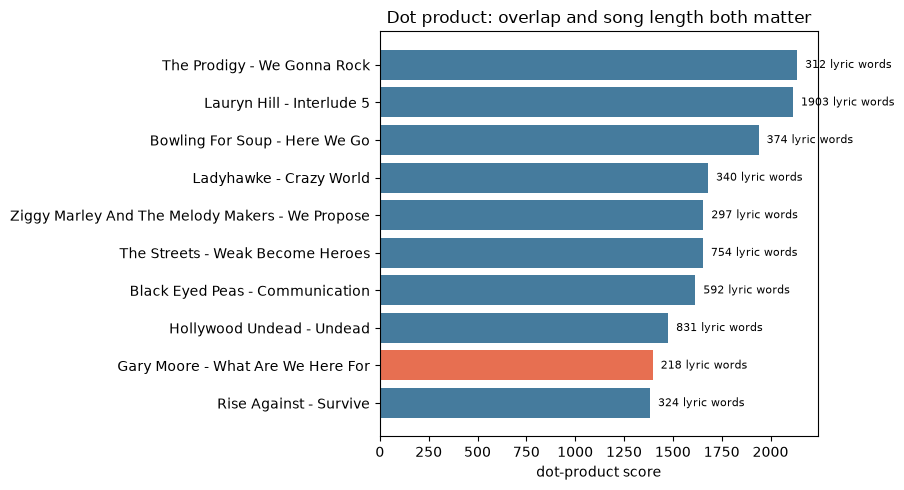

In [6]:
# Visual check: long songs can receive larger dot products.
top_dot = dot_results.sort_values("dot", ascending=False).head(10).copy()
top_dot["label"] = (
    top_dot["artist_name"].fillna("") + " - " + top_dot["song_title"].fillna("")
)
colors = ["#e76f51" if index == query_idx else "#457b9d" for index in top_dot.index]
plt.figure(figsize=(9, 5))
plt.barh(top_dot["label"], top_dot["dot"], color=colors)
for position, words in enumerate(top_dot["n_words"]):
    plt.text(top_dot["dot"].iloc[position], position, f"  {words:.0f} lyric words", va="center", fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("dot-product score")
plt.title("Dot product: overlap and song length both matter")
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Look at the top matches. Do they seem similar because they use similar words, because they are genuinely similar songs, or because the dot product is partly rewarding song size?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the raw inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

In [ ]:
# top_40_songs gets positions of songs in 'songs' and X that are in top_40

top_40_songs = songs[songs["track_id"].isin(top_40["track_id"])].index
top3_songs = []

# Creates a loop that does that dot product for every song against all the other songs except for itself
# while keeping the top three matches.
for idx in top_40_songs:
    query = X[idx]
    dot_scores = X @ query
    dot_results = songs[meta_cols].copy()
    dot_results["dot"] = dot_scores
    dot_results.loc[idx, "dot"] = -np.inf

    top_three = dot_results.sort_values("dot", ascending=False).head(3)
    top_three ["query_track_id"] = songs.loc[idx, "track_id"]
    top3_songs.append(top_three)

new_dot_results = pd.concat(top3_songs, ignore_index=True)
print(new_dot_results[['song_title', 'dot']])

                                             song_title     dot
0     B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...  2459.0
1                                             The Girls  2248.0
2                                                8 Mile  2121.0
3                                           Interlude 5  2423.0
4     B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...  2285.0
...                                                 ...     ...
1675               I'm A Winner (Amended Album Version)  4640.0
1676                                         I Want You  4321.0
1677                                        Interlude 5  7670.0
1678               I'm A Winner (Amended Album Version)  6745.0
1679                                         I Want You  6282.0

[1680 rows x 2 columns]


Interlude 5 in row 3 having a dot score of 2,423 while the same song in row 1677 having a dot score of 7,670 is evidence of the dot product rewarding song size. 

In [8]:
new_dot_results.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

## Step 2: Centering and Covariance

Now we subtract each vector's own mean. This changes the question from "Do these songs use many of the same words?" to something closer to "Do these songs rise above and below their own average on the same words?"

In [9]:
query_centered = query - query.mean()
X_centered = X - X.mean(axis=1, keepdims=True)

centered_dot_scores = X_centered @ query_centered
covariance_scores = centered_dot_scores / X.shape[1]

cov_results = songs[meta_cols].copy()
cov_results["centered_dot"] = centered_dot_scores
cov_results["covariance"] = covariance_scores
cov_results.sort_values("covariance", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,centered_dot,covariance
6290,TRFUJVJ128F426F2A2,SOONCPO12AF72A1986,AR8W8P31187B9A4063,Lauryn Hill,Interlude 5,MTV Unplugged No. 2.0,2002,734.48444,0.697206,0.580125,r&b/soul,ms hill; the realness; The Truth; true; rnb,1903,409,215.044182,0,7263.36000,9.079200
3125,TRWSYHO128F4282346,SOKHOQG12A8C13EBF2,ARSE5NP1187B9B98AB,Twista,I'm A Winner (Amended Album Version),The Day After,2005,260.23138,0.889614,0.593808,hip hop,rap; Hip-Hop; winner in bed twista,1253,166,218.622963,0,6479.24750,8.099059
6254,TREBGAA128E078FC52,SOVYGAV12A58A7C3A9,AR24DZB1187FB3C869,Erykah Badu,I Want You,Worldwide Underground,2003,653.13914,0.855732,0.584842,r&b/soul,soul; Neo-Soul; female vocalists; rnb; Erykah ...,617,98,153.163312,0,6132.54875,7.665686
2691,TRDPGXU128F9339C2A,SOELYON12AB01876A3,ARLHO5Z1187FB4C861,Beastie Boys,B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...,Paul's Boutique (20th Anniversary Remastered E...,0,105.56036,0.853125,0.591628,hip hop,hip hop; leapsandbounds CDCollection,1746,505,153.652205,0,5833.93625,7.292420
2627,TRBEBJO128C719646B,SORXHBR12AF72A5DA5,ARCBD0U1187FB466EF,Nelly,Splurge,Nellyville,2002,309.49832,0.912369,0.787995,hip hop,Hip-Hop; rap; hip hop; rnb; 00s,911,225,131.289756,0,5325.50875,6.656886
2763,TRGLNKG128F9307689,SOFVLYU12AB017F502,ARTH9041187FB43E1F,Eminem,My Darling,Relapse [Deluxe],2009,320.49587,0.871011,0.879237,hip hop,rap; detroit; Hip-Hop; Horrorcore; MOONH8SUN,1055,293,140.089257,0,5325.09875,6.656373
6390,TRKLJAG128F42B31CF,SOTGRDJ12A8C13FE2A,ARB8DSE1187FB3CFC4,Mario Vazquez,Everytime I...,Mario Vazquez,2006,241.71057,0.723005,0.395149,r&b/soul,mario vazquez; Everytime I; soul; rnb; r&b,511,114,125.658267,0,5274.68750,6.593359
6492,TROIJDA128F9341E70,SOCUXGX12A8C13B78C,ARLMXEA1187B9A7D04,R. Kelly,I Mean (I Don't Mean It),TP-2.com,2000,205.00853,0.811092,0.783843,r&b/soul,soul; rnb; english lyrics; SDZ,701,190,135.443715,0,4804.89625,6.006120
2659,TRCHZXW128E079288A,SOMEJDK12D0219BB71,ARTH9041187FB43E1F,Eminem,8 Mile,8 Mile,2002,359.39220,0.886184,0.852677,hip hop,rap; Hip-Hop; Eminem; Soundtrack; hip hop,1141,328,132.992481,0,4774.36375,5.967955
7529,TRHNOMB12903CB2544,SOGFAKF12AF72A5D66,ARPTHEU1187B98BF98,Life Without Buildings,New Town,Live at the Annandale Hotel,2000,456.82893,0.575621,0.381170,rock,indie; alternative; i wish i could write lyric...,719,74,140.160622,0,4637.21125,5.796514


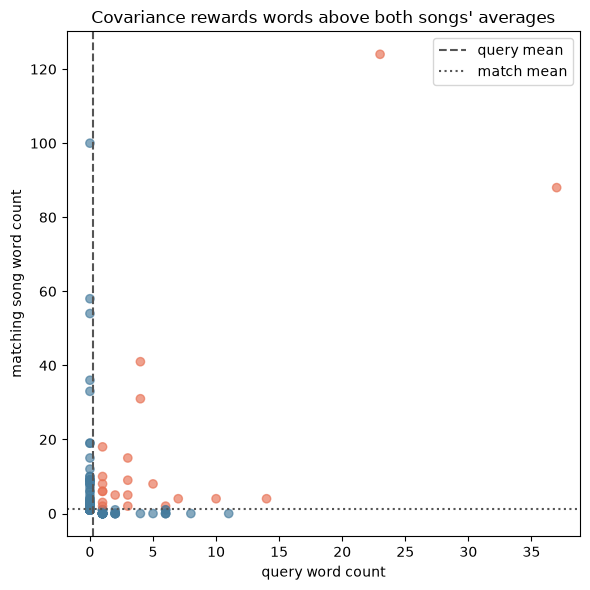

In [10]:
# Visual check: centering moves each song's average word count to zero.
comparison_idx = np.argsort(covariance_scores)[-2]
comparison = X[comparison_idx]
used_words = (query > 0) | (comparison > 0)
both_above_average = (query > query.mean()) & (comparison > comparison.mean())
plt.figure(figsize=(6, 6))
plt.scatter(query[used_words], comparison[used_words],
            c=np.where(both_above_average[used_words], "#e76f51", "#457b9d"), alpha=0.65)
plt.axvline(query.mean(), color="#555555", linestyle="--", label="query mean")
plt.axhline(comparison.mean(), color="#555555", linestyle=":", label="match mean")
plt.xlabel("query word count")
plt.ylabel("matching song word count")
plt.title("Covariance rewards words above both songs' averages")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Compare the rankings from dot product and covariance. What changed? Why does subtracting the mean change the notion of similarity?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the centered inner product. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

In [11]:
top3_cov = []
for idx in top_40_songs:
    query = X[idx]
    query_centered = query-query.mean()

    centered_dot_scores = X_centered @ query_centered
    covariance_scores = centered_dot_scores / X.shape[1]

    cov_results = songs[meta_cols].copy()
    cov_results["covariance"] = covariance_scores
    cov_results.loc[idx, "covariance"] = -np.inf

    top_three = cov_results.sort_values("covariance", ascending=False).head(3)
    top_three["query_track_id"] = songs.loc[idx, "track_id"]
    top3_cov.append(top_three)

new_cov_results = pd.concat(top3_cov, ignore_index=True)


In [12]:
print(new_cov_results[['song_title', 'covariance']])

                                             song_title  covariance
0     B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...    2.760230
1                                             The Girls    2.702012
2                                                8 Mile    2.414645
3                                           Interlude 5    2.667650
4     B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...    2.554270
...                                                 ...         ...
1675                                        Interlude 5    5.556050
1676                                         I Want You    5.275298
1677                                        Interlude 5    9.079200
1678               I'm A Winner (Amended Album Version)    8.099059
1679                                         I Want You    7.665686

[1680 rows x 2 columns]


The top of the dot rankings and covariance rankings stayed the same despite subtracting each vector's own mean. 

In [13]:
# I was having issues adding the additional covariance column to the csv without having it replace the dot column. 
# I reviewed documentation and tried using the merge() function but was still having issues.
# I ended up using an AI prompt to help debug this issue.
# The AI prompt corrected my use of the merge() function.    
combined_results = new_dot_results.merge(
    new_cov_results[["query_track_id", "track_id", "covariance"]],
    on=["query_track_id", "track_id"],
    how="outer"
)

combined_results.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

## Step 3: Correlation

Correlation takes covariance and rescales by each vector's standard deviation. That means we now compare shared pattern after accounting for both average level and spread.

In [14]:
query_std = query.std()
X_std = X.std(axis=1)

denom = X_std * query_std
corr_scores = np.divide(
    covariance_scores,
    denom,
    out=np.zeros_like(covariance_scores),
    where=denom != 0,
)

corr_results = songs[meta_cols].copy()
corr_results["correlation"] = corr_scores
corr_results.sort_values("correlation", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,correlation
7949,TRYBPGK128F4255BE3,SOMZRXL12A81C224B9,ARNBMT71187B993523,Interpol,Pace Is The Trick,Our Love To Admire,0,276.63628,0.857984,0.639882,rock,indie; indie rock; alternative; post-punk; int...,268,76,53.225934,0,1.000000
2270,TRLQBZP12903CECC4A,SOLNXMU12AB018E934,ARVWBEJ1187B9AF5CE,Hello Saferide,Get Sick Soon,Introducing Hello Saferide,2005,176.63955,0.656463,0.437877,folk,singer-songwriter; swedish; indie; female voca...,204,87,36.207734,0,0.814943
3296,TREIANS128F147AD97,SOLJYMK12A6D4F73B0,ARO7DTP1187B9A1D2B,The Puppini Sisters,I Will Survive,Betcha Bottom Dollar,2006,241.00526,0.687550,0.627259,jazz,cover; jazz; female vocalists; swing; covers,466,139,69.065187,0,0.814752
6214,TRCTLQY128F92F1539,SOTGISK12D02193153,ARVK1GC1187FB58452,Next,I Still Love You,Platinum & Gold Collection,0,254.77179,0.692430,0.543022,r&b/soul,rnb; next; soul; pop; r&b,501,102,102.878569,0,0.812836
7580,TRJOXWB128F92D8498,SONWYUI12A6D4FCF99,ARAAXVE1187FB46ACF,The Inchtabokatables,Underdrive,Ultimate Live,1992,466.59873,0.509537,0.382090,rock,indie; folk rock,290,72,54.571055,0,0.807981
621,TRFSJRW128F4292A99,SONQGWI12A8C1399B3,ARNJ9LU1187B9A56A6,Il Divo,Mama,Il Divo,2004,198.00771,0.769757,0.579216,classical,Il Divo; Classical; vocal; pop; mitsingen und ...,215,75,39.025633,0,0.807063
7508,TRGTQRM128F9330911,SOBDZQV12AB017FCA6,ARYDYH11187B9B3818,Day Of Fire,Love,Cut And Move,2006,169.45587,0.656178,0.479438,rock,christian rock; rock; metal; post-grunge; male...,359,126,52.962251,0,0.805114
6390,TRKLJAG128F42B31CF,SOTGRDJ12A8C13FE2A,ARB8DSE1187FB3CFC4,Mario Vazquez,Everytime I...,Mario Vazquez,2006,241.71057,0.723005,0.395149,r&b/soul,mario vazquez; Everytime I; soul; rnb; r&b,511,114,125.658267,0,0.803752
325,TROXHLM128F4266510,SOMPUQO12A8C13A574,ARFB30B1187FB42AB9,Blues Traveler,Hook,Live at Lollapalooza 2006: Blues Traveler,1994,254.77179,0.782883,0.473632,blues,blues rock; rock; 90s; blues; harmonica,378,161,48.062459,0,0.803059
2208,TRIGECE128F428B665,SORBDHF12A8C13C450,AR8RDYA1187FB440D9,Nikola Sarcevic,GOODBYE I DIE,LOCK SPORT KROCK,2004,220.96934,0.617662,0.370927,folk,singer-songwriter; acoustic; swedish; folk; fa...,174,56,40.706265,0,0.797980


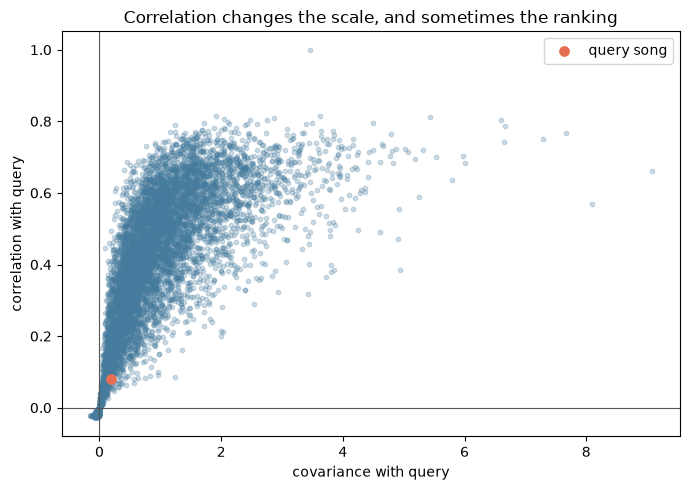

In [15]:
# Visual check: correlation rescales covariance by each song's spread.
plt.figure(figsize=(7, 5))
plt.scatter(covariance_scores, corr_scores, s=10, alpha=0.25, color="#457b9d")
plt.axhline(0, color="#555555", linewidth=0.8)
plt.axvline(0, color="#555555", linewidth=0.8)
plt.scatter(covariance_scores[query_idx], corr_scores[query_idx], color="#e76f51", s=45, label="query song")
plt.xlabel("covariance with query")
plt.ylabel("correlation with query")
plt.title("Correlation changes the scale, and sometimes the ranking")
plt.legend()
plt.tight_layout()
plt.show()

<div class="alert alert-block alert-warning">

Correlation and covariance are related, but not identical. What kind of song might move up in the ranking after standardization? What kind might move down?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using the correlation. Before sorting, set the query song's score to `-np.inf`. Save your results as additional columns in "./data/top_40_songs_by_genre_results.csv".

</div>

In [16]:
top_3_corr = []

for idx in top_40_songs:
    query = X[idx]
    query_centered = query - query.mean()
    query_std = query.std()

    centered_dot_scores = X_centered @ query_centered
    covariance_scores = centered_dot_scores/X.shape[1]

    denom = X_std * query_std
    corr_scores = np.divide(
        covariance_scores,
        denom,
        out=np.zeros_like(covariance_scores),
        where=denom != 0,
    )
    corr_results = songs[meta_cols].copy()
    corr_results["correlation"] = corr_scores
    corr_results.loc[idx, "correlation"] = -np.inf

    top_three = corr_results.sort_values("correlation", ascending=False).head(3)
    top_three["query_track_id"] = songs.loc[idx, "track_id"]
    top_3_corr.append(top_three)

new_corr_results = pd.concat(top_3_corr, ignore_index=True)


In [17]:
print(new_corr_results[['song_title', 'correlation']])

                                          song_title  correlation
0                                     I Want My Girl     0.725831
1                                         Be My Girl     0.666976
2                                     My Little Girl     0.661270
3              Hurt Me Soul (Explicit Album Version)     0.649921
4                                About Cell Block #9     0.637620
...                                              ...          ...
1675                                       Dont Cry     0.786642
1676  Don't Need The Sun To Shine (To Make Me Smile)     0.783384
1677                                   Get Sick Soon     0.814943
1678                                  I Will Survive     0.814752
1679                                I Still Love You     0.812836

[1680 rows x 2 columns]


In [18]:
combined_results = combined_results.merge(
    new_corr_results[["query_track_id", "track_id", "correlation"]],
    on=["query_track_id", "track_id"],
    how="outer"
)
combined_results.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

The types of songs that will get pushed down by correlation are the songs with lots of words. While the songs with fewer words, but are more in line with the query will move up. 

## Step 4: Cosine Similarity

Cosine similarity compares the raw vectors without centering around their means:

$$
\cos(\theta) = \frac{x \cdot y}{\|x\|\|y\|}
$$

In retrieval systems, this is often a better measure of content similarity than the raw dot product.

In [19]:
def cosine_scores(matrix, query_vector):
    numerators = matrix @ query_vector
    matrix_norms = np.linalg.norm(matrix, axis=1)
    query_norm = np.linalg.norm(query_vector)
    denominators = matrix_norms * query_norm
    return np.divide(
        numerators,
        denominators,
        out=np.zeros_like(numerators),
        where=denominators != 0,
    )


cos_scores = cosine_scores(X, query)

cosine_results = songs[meta_cols].copy()
cosine_results["cosine"] = cos_scores
cosine_results.sort_values("cosine", ascending=False).head(10)

,track_id,song_id,artist_id,artist_name,song_title,release,release_year,duration,artist_familiarity,artist_hotttnesss,genre,top_tags,n_words,nnz_words,l2_norm,is_test,cosine
7949,TRYBPGK128F4255BE3,SOMZRXL12A81C224B9,ARNBMT71187B993523,Interpol,Pace Is The Trick,Our Love To Admire,0,276.63628,0.857984,0.639882,rock,indie; indie rock; alternative; post-punk; int...,268,76,53.225934,0,1.000000
2270,TRLQBZP12903CECC4A,SOLNXMU12AB018E934,ARVWBEJ1187B9AF5CE,Hello Saferide,Get Sick Soon,Introducing Hello Saferide,2005,176.63955,0.656463,0.437877,folk,singer-songwriter; swedish; indie; female voca...,204,87,36.207734,0,0.819327
3296,TREIANS128F147AD97,SOLJYMK12A6D4F73B0,ARO7DTP1187B9A1D2B,The Puppini Sisters,I Will Survive,Betcha Bottom Dollar,2006,241.00526,0.687550,0.627259,jazz,cover; jazz; female vocalists; swing; covers,466,139,69.065187,0,0.818812
6214,TRCTLQY128F92F1539,SOTGISK12D02193153,ARVK1GC1187FB58452,Next,I Still Love You,Platinum & Gold Collection,0,254.77179,0.692430,0.543022,r&b/soul,rnb; next; soul; pop; r&b,501,102,102.878569,0,0.817231
7580,TRJOXWB128F92D8498,SONWYUI12A6D4FCF99,ARAAXVE1187FB46ACF,The Inchtabokatables,Underdrive,Ultimate Live,1992,466.59873,0.509537,0.382090,rock,indie; folk rock,290,72,54.571055,0,0.812506
621,TRFSJRW128F4292A99,SONQGWI12A8C1399B3,ARNJ9LU1187B9A56A6,Il Divo,Mama,Il Divo,2004,198.00771,0.769757,0.579216,classical,Il Divo; Classical; vocal; pop; mitsingen und ...,215,75,39.025633,0,0.811679
7508,TRGTQRM128F9330911,SOBDZQV12AB017FCA6,ARYDYH11187B9B3818,Day Of Fire,Love,Cut And Move,2006,169.45587,0.656178,0.479438,rock,christian rock; rock; metal; post-grunge; male...,359,126,52.962251,0,0.809517
6390,TRKLJAG128F42B31CF,SOTGRDJ12A8C13FE2A,ARB8DSE1187FB3CFC4,Mario Vazquez,Everytime I...,Mario Vazquez,2006,241.71057,0.723005,0.395149,r&b/soul,mario vazquez; Everytime I; soul; rnb; r&b,511,114,125.658267,0,0.807233
325,TROXHLM128F4266510,SOMPUQO12A8C13A574,ARFB30B1187FB42AB9,Blues Traveler,Hook,Live at Lollapalooza 2006: Blues Traveler,1994,254.77179,0.782883,0.473632,blues,blues rock; rock; 90s; blues; harmonica,378,161,48.062459,0,0.807218
2208,TRIGECE128F428B665,SORBDHF12A8C13C450,AR8RDYA1187FB440D9,Nikola Sarcevic,GOODBYE I DIE,LOCK SPORT KROCK,2004,220.96934,0.617662,0.370927,folk,singer-songwriter; acoustic; swedish; folk; fa...,174,56,40.706265,0,0.802168


<div class="alert alert-block alert-warning">

Compare the dot-product ranking to the cosine-similarity ranking. Which one seems more like a "similar songs" engine and which one seems more like a "shares lots of raw word mass" engine?

Adapt the above code chunks to find the top three **non-self** matches for all of the Top 40 songs by genre using cosine similarity. Before sorting, set the query song's score to `-np.inf`. Save your results as another column in "./data/top_40_songs_by_genre_results.csv".

</div>

In [20]:
top3_cos = []
for idx in top_40_songs:
    query = X[idx]
    cos_scores = cosine_scores(X, query)

    cosine_results = songs[meta_cols].copy()
    cosine_results["cosine"] = cos_scores
    cosine_results.loc[idx, "cosine"] = -np.inf

    top_three = cosine_results.sort_values("cosine", ascending=False).head(3)
    top_three["query_track_id"] = songs.loc[idx, "track_id"]
    top3_cos.append(top_three)

new_cosine_results = pd.concat(top3_cos, ignore_index=True)

In [21]:
print(new_cosine_results[['song_title', 'cosine']])

                                          song_title    cosine
0                                     I Want My Girl  0.735841
1                                         Be My Girl  0.675138
2                                     My Little Girl  0.674837
3              Hurt Me Soul (Explicit Album Version)  0.666468
4                                            Feel Me  0.656912
...                                              ...       ...
1675                                       Dont Cry  0.791077
1676  Don't Need The Sun To Shine (To Make Me Smile)  0.787707
1677                                   Get Sick Soon  0.819327
1678                                  I Will Survive  0.818812
1679                                I Still Love You  0.817231

[1680 rows x 2 columns]


The cosine-similarity ranking did a better job of ranking songs based on "similarity" than the dot product, just based on the eye test. The top three songs in the cosine-similarity ranking are centered around the same subject, while the dot product ranges from Eminem to Lauryn Hill.

In [22]:
combined_results = combined_results.merge(
    new_cosine_results[["query_track_id", "track_id", "cosine"]],
    on=["query_track_id", "track_id"],
    how="outer"
)
combined_results.to_csv("./data/top_40_songs_by_genre_results.csv", index=False)

<div class="alert alert-block alert-warning">

For the Top 40 songs, do you notice any patterns across the inner product, correlation, and cosine similarity top three recommendations you provided? Is there significant agreement, or do the recommendations change significantly by method?

Which methods are most in agreement?

Which methods do you think give the best results?

</div>

There were similar results between the dot product and centering/covariance. Similarly, the correlation and cosine methods had the same top results. I think that the correlation and cosine methods gave the best results because they devalued large word counts and their resulting rankings had songs that were actually of the same genre. 

## Step 5:

Some words are "outliers": They appear in many songs with overwhelming frequency. For example, "love" is a common word in songs. That will boost the inner product significantly. Conversely, rare words like "amortization" or "zebra" might be rare and important for matching, but receive the same weight as a generic word like "about".

There is a useful technology to deal with this. We're going to cover one way of implementing it.

- Step 1: Compute the **term frequency** of each song-word pair, by taking $\log(1+x_{song,word})$. This is a matrix, $TF$. This transformation reduces the marginal importance of common words.
- Step 2: Compute the **inverse document frequency** of each word. Let $N$ be the number of documents. Let $df_w$ be the document frequency of word $w$, the num of documents in which word $w$ appears. Then $IDF_w = \log( N / df_w)$.

The **TF-IDF** matrix reweights the $TF$ matrix by the $IDF$ vector: $TFIDF = TF 	imes IDF$. This transformed matrix is then used for retrieval calculations (raw inner product, centered inner product, correlation, cosine similarity), instead of the raw word counts.

In [23]:
# Term frequency: repeated uses of one word count less and less.
TF = np.log1p(X) # Compute TF

# Document frequency: how many songs use each word at least once.
N = X.shape[0] # Determine number of documents
df = (X > 0).sum(axis=0) # Compute document frequency
IDF = np.log(N / df) # Compute IDF

# IDF is one number per word, so NumPy broadcasts it across every song row.
TFIDF = TF * IDF

print(pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=True).head(10))

print( pd.DataFrame({
    "word": word_cols,
    "document_frequency": df,
    "idf": IDF,
}).sort_values("idf", ascending=False).head(10) )

     word  document_frequency       idf
324     i                5966  0.293365
22    and                5960  0.294371
795   you                5671  0.344076
409    me                5420  0.389346
331    in                5345  0.403280
334    is                5191  0.432515
336    it                5045  0.461044
466   not                4961  0.477834
475    of                4785  0.513956
662  that                4597  0.554038
     word  document_frequency       idf
176   doo                  26  5.729100
258  funk                  48  5.115996
726   ven                  56  4.961845
327   ihr                  59  4.909659
770   wir                  60  4.892852
201    er                  63  4.844062
711     u                  66  4.797542
162  dich                  68  4.767689
596   sie                  78  4.630488
208    eu                  81  4.592748


<div class="alert alert-block alert-warning">

Do you notice any patterns among the lowest and highest IDF words?

Rerun your results from the previous steps to use raw inner product, centered inner product, correlation, and cosine similarity to generate new top 3 **non-self** recommendations for the top 40 songs.

How do the new TF-IDF-based recommendations compare to one another and the original recommendations?

</div>

The highest IDF words are common words that essentially make up basic sentence structure. Whereas the lowest IDF words are rare words that belong in Scrabble.  

In [32]:
top3_dot_songs = []
for idx in top_40_songs:
    query = TFIDF[idx]
    dot_scores = TFIDF @ query
    dot_results = songs[meta_cols].copy()
    dot_results["dot"] = dot_scores
    dot_results.loc[idx, "dot"] = -np.inf

    top_three = dot_results.sort_values("dot", ascending=False).head(3)
    top_three ["query_track_id"] = songs.loc[idx, "track_id"]
    top3_dot_songs.append(top_three)

new_dot_results2 = pd.concat(top3_dot_songs, ignore_index=True)
print(new_dot_results2[['song_title', 'dot']])

                                             song_title         dot
0                                      She Ain't Afraid  183.644475
1     B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...  182.499774
2                                           Interlude 5  178.804204
3     B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...  176.585788
4                                           Interlude 5  167.981338
...                                                 ...         ...
1675                                Let's All Get Drunk  100.667780
1676                                   Out of Character   93.897826
1677                                         She Luv It  141.122817
1678                                           Mamacita  136.416486
1679  B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...  133.906317

[1680 rows x 2 columns]


The raw dot results with TFIDF changed the top song but the Beastie Boys and Lauryn Hill remained. The dot scores also dropped across the board.

In [29]:
TFIDF_centered = TFIDF - TFIDF.mean(axis=1, keepdims=True)
top3_cov_new = []
for idx in top_40_songs:
    query = TFIDF[idx]
    query_centered = query-query.mean()

    centered_dot_scores = TFIDF_centered @ query_centered
    covariance_scores = centered_dot_scores / TFIDF.shape[1]

    cov_results = songs[meta_cols].copy()
    cov_results["covariance"] = covariance_scores
    cov_results.loc[idx, "covariance"] = -np.inf

    top_three = cov_results.sort_values("covariance", ascending=False).head(3)
    top_three["query_track_id"] = songs.loc[idx, "track_id"]
    top3_cov_new.append(top_three)

new_cov_results2 = pd.concat(top3_cov_new, ignore_index=True)
print(new_cov_results2[['song_title', 'covariance']])

                                       song_title  covariance
0                                She Ain't Afraid    0.144671
1                       Guajira (I Love U 2 Much)    0.135971
2                             What's On Your Mind    0.127510
3                          That's How I Beat Shaq    0.135044
4     If I Had My Way I'd Tear This Building Down    0.128281
...                                           ...         ...
1675                         Someone i care about    0.099474
1676                                      Alright    0.099142
1677                                     Mamacita    0.145145
1678                                   She Luv It    0.132609
1679                        I'll Make Love To You    0.111126

[1680 rows x 2 columns]


The centered inner product changed significantly from the previous results with the new results having a narrower range.

In [30]:
top_3_corr_new = []
TFIDF_std = TFIDF.std(axis=1)
for idx in top_40_songs:
    query = TFIDF[idx]
    query_centered = query - query.mean()
    query_std = query.std()

    centered_dot_scores = TFIDF_centered @ query_centered
    covariance_scores = centered_dot_scores/TFIDF.shape[1]

    denom = TFIDF_std * query_std
    corr_scores = np.divide(
        covariance_scores,
        denom,
        out=np.zeros_like(covariance_scores),
        where=denom != 0,
    )
    corr_results = songs[meta_cols].copy()
    corr_results["correlation"] = corr_scores
    corr_results.loc[idx, "correlation"] = -np.inf

    top_three = corr_results.sort_values("correlation", ascending=False).head(3)
    top_three["query_track_id"] = songs.loc[idx, "track_id"]
    top_3_corr_new.append(top_three)

new_corr_results2 = pd.concat(top_3_corr_new, ignore_index=True)

print(new_corr_results2[['song_title', 'correlation']])

                                  song_title  correlation
0                      The Girl That I Marry     0.312876
1                                   Cavatina     0.296103
2                         The Girl Next Door     0.291793
3                              Stormy Monday     0.286969
4                        Down At The Landing     0.243375
...                                      ...          ...
1675                    Someone i care about     0.360202
1676  Who Cares (So Long As You Care For Me)     0.313956
1677                                   Today     0.299172
1678                                Mamacita     0.285921
1679                      Saturday Come Slow     0.256478

[1680 rows x 2 columns]


The new correlation results with TFIDF put new songs at the top with lower, but more realistic correlation values.

In [31]:
top3_cos_new = []
for idx in top_40_songs:
    query = TFIDF[idx]
    cos_scores = cosine_scores(TFIDF, query)

    cosine_results = songs[meta_cols].copy()
    cosine_results["cosine"] = cos_scores
    cosine_results.loc[idx, "cosine"] = -np.inf

    top_three = cosine_results.sort_values("cosine", ascending=False).head(3)
    top_three["query_track_id"] = songs.loc[idx, "track_id"]
    top3_cos_new.append(top_three)

new_cosine_results2 = pd.concat(top3_cos_new, ignore_index=True)

print(new_cosine_results2[['song_title', 'cosine']])

                 song_title    cosine
0     The Girl That I Marry  0.335758
1                  Cavatina  0.331226
2        The Girl Next Door  0.327615
3             Stormy Monday  0.315001
4           Since Yesterday  0.276377
...                     ...       ...
1675   Someone i care about  0.384121
1676           It's Alright  0.340549
1677                  Today  0.329578
1678               Mamacita  0.319854
1679          Love Don't Do  0.288084

[1680 rows x 2 columns]


Similar to the new correlation results, the new cosine results had different songs at the top and also aligned closely with the correlaiton scores.

## Part 2: Evaluate a Genre Retrieval System

To engineer a system, we need a ground truth for success or failure. In practice, we would have experts label a dataset or observe user responses and infer success or failure (success might mean they continue their session and click on one of our recommendations, and failure means their session continues but they search for new songs on their own). In the absence of a ground truth, we can use the song genre.

So your job is:

1. For every Top-40 query song, remove the query song itself and every song by the same artist before selecting the top three recommendations for raw inner product, cosine similarity, and TF-IDF-based cosine similarity. If a recommendation's genre matches the query song's genre, record a hit (`True`); otherwise record a miss (`False`). Report `hits.mean()`: this is mean **precision@3**, the share of all recommendation slots that are same-genre hits. Do not hard-code the denominator.
2. Using the ideas from step 1, try to engineer a system that outperforms the available baselines. What matters is your explanation for why you designed the system you did, not whether or not it outperforms the baselines.
3. Write up your results in a separate text file, as a report on your work as a data engineer. Do the existing options work well, or did you find ways to outperform it?


In [ ]:
top3_dot_songs2 = []
hits = []
for idx in top_40_songs:
    query = X[idx]
    dot_scores = X @ query
    dot_results = songs[meta_cols].copy()
    dot_results["dot"] = dot_scores
    dot_results.loc[idx, "dot"] = -np.inf

    query_artist = songs.loc[idx, 'artist_id'] #getting the artist id
    exclude = (dot_results.index == idx) | (songs["artist_id"] == query_artist) # building a mask to mark which rows to exclude
    dot_results = dot_results[~exclude]

    top_three = dot_results.sort_values("dot", ascending=False).head(3)
    top_three ["query_track_id"] = songs.loc[idx, "track_id"]
    top3_dot_songs2.append(top_three)

    query_genre = songs.loc[idx, "genre"] 
    hits.extend(top_three["genre"] == query_genre) # Putting the boolean values into hits[]

precision3 = np.array(hits)
new_dot_results3 = pd.concat(top3_dot_songs2, ignore_index=True)

print(new_dot_results3[['song_title', 'dot']])
print("Precision@3:", precision3.mean())

                                             song_title     dot
0     B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...  2459.0
1                                             The Girls  2248.0
2                                                8 Mile  2121.0
3                                           Interlude 5  2423.0
4     B-Boy Bouillabaisse: A.W.O.L. (2009 Digital Re...  2285.0
...                                                 ...     ...
1675               I'm A Winner (Amended Album Version)  4640.0
1676                                         I Want You  4321.0
1677                                        Interlude 5  7670.0
1678               I'm A Winner (Amended Album Version)  6745.0
1679                                         I Want You  6282.0

[1680 rows x 2 columns]
Precision@3: 0.09285714285714286


In [41]:
new_top3_cos = []
hits_cos = []
for idx in top_40_songs:
    query = X[idx]
    cos_scores = cosine_scores(X, query)

    cosine_results = songs[meta_cols].copy()
    cosine_results["cosine"] = cos_scores
    cosine_results.loc[idx, "cosine"] = -np.inf

    query_artist = songs.loc[idx, "artist_id"]
    exclude = (cosine_results.index == idx) | (songs["artist_id"] == query_artist)

    top_three = cosine_results.sort_values("cosine", ascending=False).head(3)
    top_three["query_track_id"] = songs.loc[idx, "track_id"]
    new_top3_cos.append(top_three)

    query_genre = songs.loc[idx, "genre"]
    hits_cos.extend(top_three["genre"] == query_genre)

new_cosine_results = pd.concat(new_top3_cos, ignore_index=True)
cos_precision3 = np.array(hits_cos)

print(new_cosine_results[['song_title', 'cosine']])
print("Precision@3:", cos_precision3.mean())

                                          song_title    cosine
0                                     I Want My Girl  0.735841
1                                         Be My Girl  0.675138
2                                     My Little Girl  0.674837
3              Hurt Me Soul (Explicit Album Version)  0.666468
4                                            Feel Me  0.656912
...                                              ...       ...
1675                                       Dont Cry  0.791077
1676  Don't Need The Sun To Shine (To Make Me Smile)  0.787707
1677                                   Get Sick Soon  0.819327
1678                                  I Will Survive  0.818812
1679                                I Still Love You  0.817231

[1680 rows x 2 columns]
Precision@3: 0.19583333333333333


In [43]:
top3_cos_new2 = []
hits_cos2 = []
for idx in top_40_songs:
    query = TFIDF[idx]
    cos_scores = cosine_scores(TFIDF, query)

    cosine_results = songs[meta_cols].copy()
    cosine_results["cosine"] = cos_scores
    cosine_results.loc[idx, "cosine"] = -np.inf

    query_artist = songs.loc[idx, "artist_id"]
    exclude = (cosine_results.index == idx) | (songs["artist_id"] == query_artist)
    cosine_results = cosine_results[~exclude]

    top_three = cosine_results.sort_values("cosine", ascending=False).head(3)
    top_three["query_track_id"] = songs.loc[idx, "track_id"]
    top3_cos_new2.append(top_three)

    query_genre = songs.loc[idx, "genre"]
    hits_cos2.extend(top_three["genre"] == query_genre)


new_cosine_results3 = pd.concat(top3_cos_new2, ignore_index=True)
hits_cos2 = np.array(hits_cos2)
print(new_cosine_results3[['song_title', 'cosine']])
print("Precision@3:", hits_cos2.mean())

                 song_title    cosine
0     The Girl That I Marry  0.335758
1                  Cavatina  0.331226
2        The Girl Next Door  0.327615
3             Stormy Monday  0.315001
4           Since Yesterday  0.276377
...                     ...       ...
1675   Someone i care about  0.384121
1676           It's Alright  0.340549
1677                  Today  0.329578
1678               Mamacita  0.319854
1679          Love Don't Do  0.288084

[1680 rows x 2 columns]
Precision@3: 0.21011904761904762


In [44]:
# New system

# The new system will get rid of rare words that don't appear in at least three songs. 
# This is inspired from step 5, where the highest IDF words were things like "doo" and "wir"
# The purpose of doing this is so that the new TFIDF won't weigh these irrevelvant words so high and so more relevant words can be weighed higher.

min_df = 3
words = df>= min_df

X_trimmed = X[:, words]

TF2 = np.log1p(X_trimmed)
N2 = X_trimmed.shape[0]
df2 = (X_trimmed > 0 ).sum(axis=0)
IDF2 = np.log(N2/df2)
TFIDF2 = TF2 * IDF2

In [46]:
top3_cos_new3 = []
hits_cos3 = []
for idx in top_40_songs:
    query = TFIDF2[idx]
    cos_scores = cosine_scores(TFIDF, query)

    cosine_results = songs[meta_cols].copy()
    cosine_results["cosine"] = cos_scores
    cosine_results.loc[idx, "cosine"] = -np.inf

    query_artist = songs.loc[idx, "artist_id"]
    exclude = (cosine_results.index == idx) | (songs["artist_id"] == query_artist)
    cosine_results = cosine_results[~exclude]

    top_three = cosine_results.sort_values("cosine", ascending=False).head(3)
    top_three["query_track_id"] = songs.loc[idx, "track_id"]
    top3_cos_new3.append(top_three)

    query_genre = songs.loc[idx, "genre"]
    hits_cos3.extend(top_three["genre"] == query_genre)


new_cosine_results4 = pd.concat(top3_cos_new3, ignore_index=True)
hits_cos3 = np.array(hits_cos3)
print(new_cosine_results4[['song_title', 'cosine']])
print("Precision@3:", hits_cos3.mean())

                 song_title    cosine
0     The Girl That I Marry  0.335758
1                  Cavatina  0.331226
2        The Girl Next Door  0.327615
3             Stormy Monday  0.315001
4           Since Yesterday  0.276377
...                     ...       ...
1675   Someone i care about  0.384121
1676           It's Alright  0.340549
1677                  Today  0.329578
1678               Mamacita  0.319854
1679          Love Don't Do  0.288084

[1680 rows x 2 columns]
Precision@3: 0.21011904761904762
